# 1. Pemanggilan Data

In [ ]:
import pandas as pd
import pandas as pd
import numpy
from matplotlib import pyplot
from google.colab import drive
drive.mount('/content/drive')
# Baca file CSV dari Google Drive
df = pd.read_csv('/content/drive/My Drive/Portofolio Colab/market_pipe_thickness_loss_dataset.csv')

# Tampilkan beberapa baris pertama dari DataFrame
print(df.head())



Mounted at /content/drive
   Pipe_Size_mm  Thickness_mm      Material              Grade  \
0           800         15.48  Carbon Steel  ASTM A333 Grade 6   
1           800         22.00           PVC  ASTM A106 Grade B   
2           400         12.05  Carbon Steel         API 5L X52   
3          1500         38.72  Carbon Steel         API 5L X42   
4          1500         24.32          HDPE         API 5L X65   

   Max_Pressure_psi  Temperature_C  Corrosion_Impact_Percent  \
0               300           84.9                     16.04   
1               150           14.1                      7.38   
2              2500            0.6                      2.12   
3              1500           52.7                      5.58   
4              1500           11.7                     12.29   

   Thickness_Loss_mm  Material_Loss_Percent  Time_Years Condition  
0               4.91                  31.72           2  Moderate  
1               7.32                  33.27           4 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pipe_Size_mm              1000 non-null   int64  
 1   Thickness_mm              1000 non-null   float64
 2   Material                  1000 non-null   object 
 3   Grade                     1000 non-null   object 
 4   Max_Pressure_psi          1000 non-null   int64  
 5   Temperature_C             1000 non-null   float64
 6   Corrosion_Impact_Percent  1000 non-null   float64
 7   Thickness_Loss_mm         1000 non-null   float64
 8   Material_Loss_Percent     1000 non-null   float64
 9   Time_Years                1000 non-null   int64  
 10  Condition                 1000 non-null   object 
dtypes: float64(5), int64(3), object(3)
memory usage: 86.1+ KB


In [ ]:
df.isnull().sum()

,0
Pipe_Size_mm,0
Thickness_mm,0
Material,0
Grade,0
Max_Pressure_psi,0
Temperature_C,0
Corrosion_Impact_Percent,0
Thickness_Loss_mm,0
Material_Loss_Percent,0
Time_Years,0


In [ ]:
# Mengganti nilai NaN dengan 0 di semua kolom
df = df.fillna(0)

In [ ]:
df.describe()

,Pipe_Size_mm,Thickness_mm,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,522.000000,16.073530,1004.100000,42.595600,9.745990,4.886300,46.747560,12.961000
std,443.703587,10.548358,812.843099,41.127071,5.817492,2.901123,46.602553,7.135993
min,50.000000,3.000000,150.000000,-50.000000,0.000000,0.010000,0.080000,1.000000
25%,150.000000,7.357500,300.000000,13.400000,4.492500,2.365000,15.665000,7.000000
50%,300.000000,12.930000,900.000000,41.200000,9.720000,4.915000,31.660000,13.000000
75%,800.000000,23.027500,1500.000000,69.150000,14.832500,7.432500,61.035000,19.000000
max,1500.000000,49.530000,2500.000000,149.700000,20.000000,9.990000,318.750000,25.000000


In [ ]:
df.head(5)

,Pipe_Size_mm,Thickness_mm,Material,Grade,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition
0,800,15.48,Carbon Steel,ASTM A333 Grade 6,300,84.9,16.04,4.91,31.72,2,Moderate
1,800,22.00,PVC,ASTM A106 Grade B,150,14.1,7.38,7.32,33.27,4,Critical
2,400,12.05,Carbon Steel,API 5L X52,2500,0.6,2.12,6.32,52.45,7,Critical
3,1500,38.72,Carbon Steel,API 5L X42,1500,52.7,5.58,6.20,16.01,19,Critical
4,1500,24.32,HDPE,API 5L X65,1500,11.7,12.29,8.58,35.28,20,Critical


<Axes: >

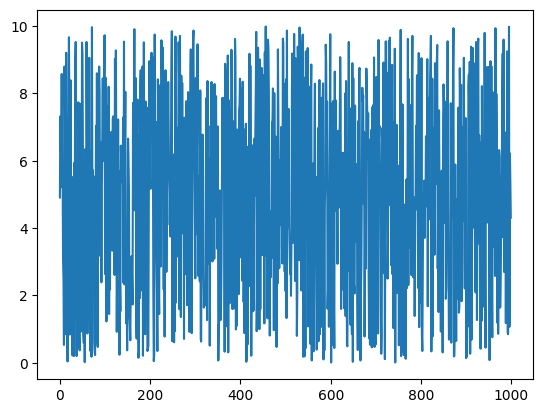

In [ ]:
df['Thickness_Loss_mm'].plot()

In [ ]:
# Pemilihan Fitur
df = df.drop(['Grade', 'Max_Pressure_psi', 'Temperature_C', 'Corrosion_Impact_Percent'], axis=1)
df.head()

,Pipe_Size_mm,Thickness_mm,Material,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition
0,800,15.48,Carbon Steel,4.91,31.72,2,Moderate
1,800,22.00,PVC,7.32,33.27,4,Critical
2,400,12.05,Carbon Steel,6.32,52.45,7,Critical
3,1500,38.72,Carbon Steel,6.20,16.01,19,Critical
4,1500,24.32,HDPE,8.58,35.28,20,Critical


Encoding Kategorikal dan Analisis Korelasi

In [ ]:
# One-hot encode 'Material' and 'Condition' columns
df_encoded = pd.get_dummies(df, columns=['Material', 'Condition'])

# Calculate and display the correlation matrix
correlations = df_encoded.corr()['Thickness_Loss_mm'].sort_values(kind='quicksort')
display(correlations)

,Thickness_Loss_mm
Condition_Normal,-0.712954
Condition_Moderate,-0.304803
Material_Carbon Steel,-0.050161
Time_Years,-0.012600
Material_Stainless Steel,-0.007122
Material_HDPE,-0.006941
Material_Fiberglass,0.002635
Thickness_mm,0.049979
Pipe_Size_mm,0.063189
Material_PVC,0.063954


In [ ]:
values=df.values;

In [ ]:
df.head()

,Pipe_Size_mm,Thickness_mm,Material,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition
0,800,15.48,Carbon Steel,4.91,31.72,2,Moderate
1,800,22.00,PVC,7.32,33.27,4,Critical
2,400,12.05,Carbon Steel,6.32,52.45,7,Critical
3,1500,38.72,Carbon Steel,6.20,16.01,19,Critical
4,1500,24.32,HDPE,8.58,35.28,20,Critical


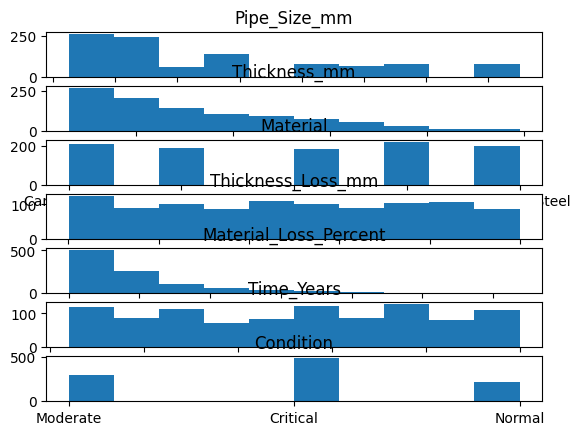

In [ ]:
# Update groups to reflect the current columns in df
groups = range(len(df.columns))

i=1
pyplot.figure()
for group in groups:
  pyplot.subplot((len(groups)),1,i)
  pyplot.hist(values[:,group])
  pyplot.title(df.columns[group])
  i+=1
pyplot.show()

In [ ]:
values.shape

(1000, 7)

# 2. Pengolahan Data

## Preprocessing data

### Subtask:
Melakukan pra-pemrosesan data, termasuk penanganan nilai yang hilang (jika ada) dan encoding variabel kategorikal.


In [ ]:
# Check for missing values again
print(df.isnull().sum())

# One-hot encode 'Material' and 'Condition' columns
df_encoded = pd.get_dummies(df, columns=['Material', 'Condition'])

# Display the first few rows of the encoded DataFrame
print(df_encoded.head())

Pipe_Size_mm             0
Thickness_mm             0
Material                 0
Thickness_Loss_mm        0
Material_Loss_Percent    0
Time_Years               0
Condition                0
dtype: int64
   Pipe_Size_mm  Thickness_mm  Thickness_Loss_mm  Material_Loss_Percent  \
0           800         15.48               4.91                  31.72   
1           800         22.00               7.32                  33.27   
2           400         12.05               6.32                  52.45   
3          1500         38.72               6.20                  16.01   
4          1500         24.32               8.58                  35.28   

   Time_Years  Material_Carbon Steel  Material_Fiberglass  Material_HDPE  \
0           2                   True                False          False   
1           4                  False                False          False   
2           7                   True                False          False   
3          19                   True       

## Analisis Outlier

### Subtask:
Memvisualisasikan outlier pada fitur-fitur numerik menggunakan box plot.

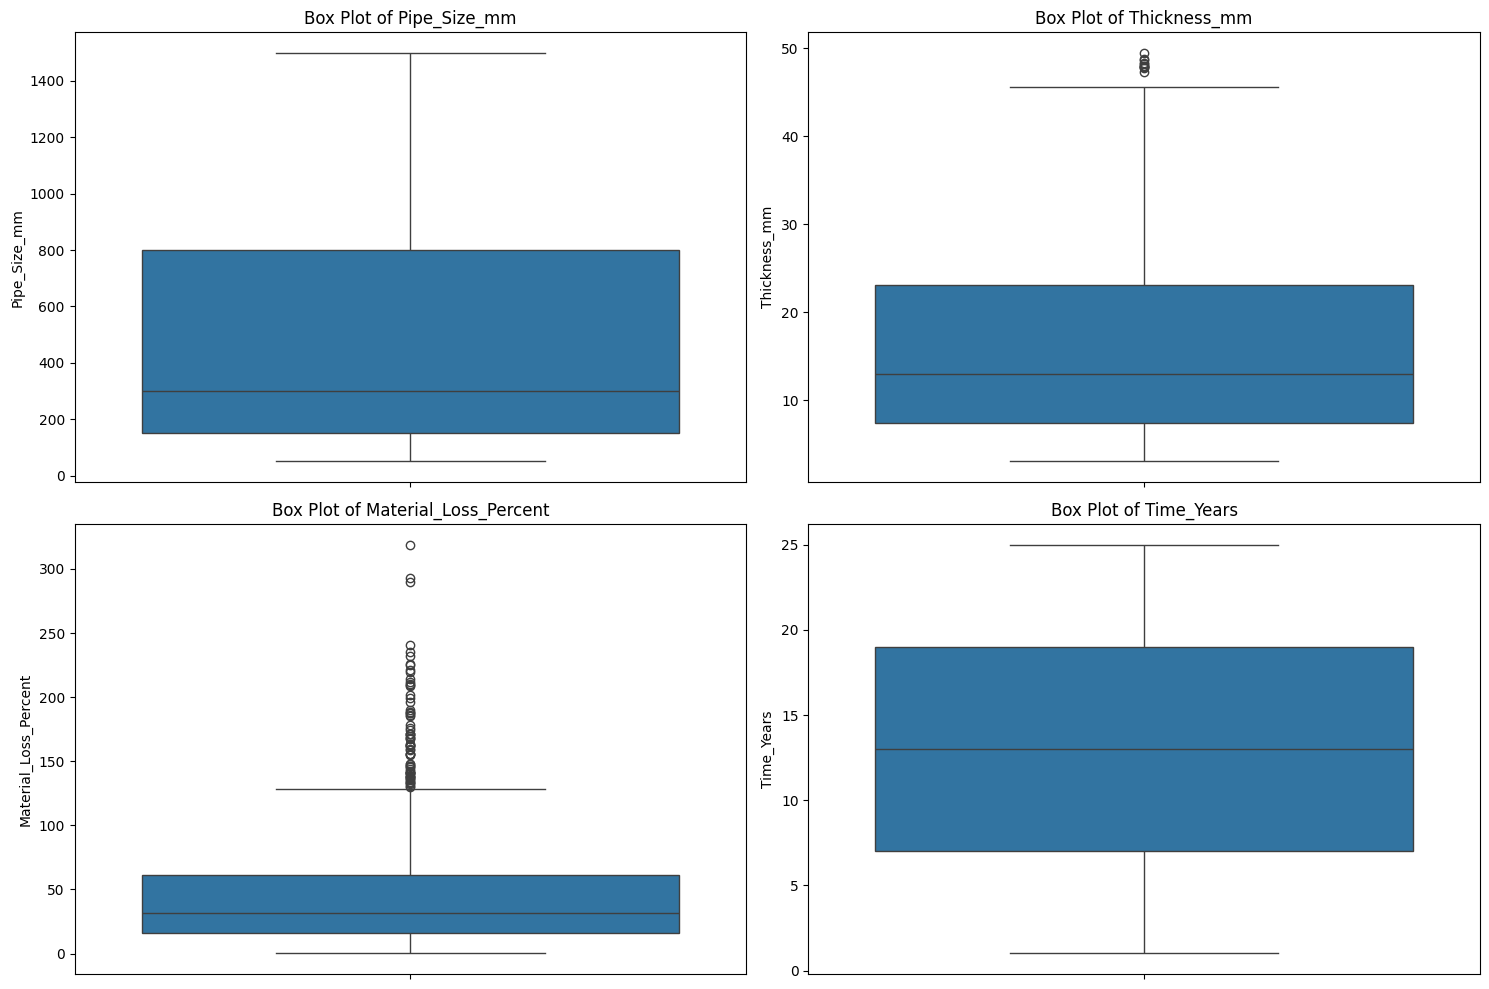

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier analysis
numerical_cols_for_outliers = ['Pipe_Size_mm', 'Thickness_mm', 'Material_Loss_Percent', 'Time_Years']

# Create box plots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Normalisasi Data

### Subtask:
Melakukan normalisasi pada fitur-fitur numerik.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns (excluding the target and one-hot encoded columns)
numerical_cols = ['Pipe_Size_mm', 'Thickness_mm', 'Material_Loss_Percent', 'Time_Years']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns in the encoded DataFrame
# Fit on the training data and transform both training and testing data
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# Display the first few rows of the normalized DataFrame
print("DataFrame after Normalization:")
display(df_encoded.head())

DataFrame after Normalization:


,Pipe_Size_mm,Thickness_mm,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Material_Carbon Steel,Material_Fiberglass,Material_HDPE,Material_PVC,Material_Stainless Steel,Condition_Critical,Condition_Moderate,Condition_Normal
0,0.626858,-0.056296,4.91,-0.322624,-1.536785,True,False,False,False,False,False,True,False
1,0.626858,0.562119,7.32,-0.289347,-1.256375,False,False,False,True,False,True,False,False
2,-0.275096,-0.381627,6.32,0.122424,-0.835761,True,False,False,False,False,True,False,False
3,2.205277,2.147993,6.20,-0.659898,0.846697,True,False,False,False,False,True,False,False
4,2.205277,0.782169,8.58,-0.246195,0.986901,False,False,True,False,False,True,False,False


## Pemilihan fitur

### Subtask:
Memilih fitur-fitur yang relevan untuk model.


In [ ]:
# Select features based on correlation analysis and domain knowledge.
# Columns with significant correlation to 'Thickness_Loss_mm' were identified in the previous step.
# We will also include 'Pipe_Size_mm', 'Thickness_mm', 'Time_Years', and one-hot encoded 'Material' and 'Condition'.
features = df_encoded[['Pipe_Size_mm', 'Thickness_mm', 'Material_Loss_Percent', 'Time_Years',
                       'Material_Carbon Steel', 'Material_Fiberglass', 'Material_HDPE', 'Material_PVC', 'Material_Stainless Steel',
                       'Condition_Critical', 'Condition_Moderate', 'Condition_Normal']]

# Select the target variable
target = df_encoded['Thickness_Loss_mm']

# Display the first few rows of the features and target DataFrames
print("Features:")
display(features.head())
print("\nTarget:")
display(target.head())

Features:


,Pipe_Size_mm,Thickness_mm,Material_Loss_Percent,Time_Years,Material_Carbon Steel,Material_Fiberglass,Material_HDPE,Material_PVC,Material_Stainless Steel,Condition_Critical,Condition_Moderate,Condition_Normal
0,0.626858,-0.056296,-0.322624,-1.536785,True,False,False,False,False,False,True,False
1,0.626858,0.562119,-0.289347,-1.256375,False,False,False,True,False,True,False,False
2,-0.275096,-0.381627,0.122424,-0.835761,True,False,False,False,False,True,False,False
3,2.205277,2.147993,-0.659898,0.846697,True,False,False,False,False,True,False,False
4,2.205277,0.782169,-0.246195,0.986901,False,False,True,False,False,True,False,False



Target:


,Thickness_Loss_mm
0,4.91
1,7.32
2,6.32
3,6.20
4,8.58


## Pembagian data

### Subtask:
Membagi data menjadi set pelatihan dan pengujian.


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Print the shapes of the resulting datasets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (700, 12)
Shape of X_test: (300, 12)
Shape of y_train: (700,)
Shape of y_test: (300,)


# 3. Pelatihan Model

## Pembuatan dan pelatihan model (LSTM dengan data ternormalisasi)

### Subtask:
Membangun dan melatih model regresi LSTM menggunakan data yang sudah dinormalisasi.

In [ ]:
from sklearn.linear_model import LinearRegression

# Instantiate a LinearRegression model object
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np

# Ensure X_train and X_test are float32 after normalization
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Reshape data for LSTM (samples, timesteps, features)
# Assuming each sample is a single timestep
X_train_lstm = np.reshape(X_train.values, (X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.reshape(X_test.values, (X_test.shape[0], 1, X_test.shape[1]))

# Define the LSTM model (using the architecture that previously gave R2 ~0.958)
model_lstm_normalized = Sequential()
model_lstm_normalized.add(LSTM(50, activation='relu', input_shape=(1, X_train.shape[1])))
model_lstm_normalized.add(Dense(1)) # Output layer for regression

# Compile the model
model_lstm_normalized.compile(optimizer='adam', loss='mse')

# Train the model
history_normalized = model_lstm_normalized.fit(X_train_lstm, y_train, epochs=100, batch_size=32, validation_data=(X_test_lstm, y_test), verbose=2)

# Evaluate the model
loss_normalized = model_lstm_normalized.evaluate(X_test_lstm, y_test, verbose=0)
print(f"Test Loss (MSE) after training with normalized data: {loss_normalized}")

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 - 3s - 130ms/step - loss: 31.1018 - val_loss: 29.8555
Epoch 2/100
22/22 - 0s - 9ms/step - loss: 29.2868 - val_loss: 27.8120
Epoch 3/100
22/22 - 0s - 7ms/step - loss: 26.7365 - val_loss: 24.8203
Epoch 4/100
22/22 - 0s - 7ms/step - loss: 23.2006 - val_loss: 20.7718
Epoch 5/100
22/22 - 0s - 13ms/step - loss: 18.7208 - val_loss: 16.1304
Epoch 6/100
22/22 - 0s - 15ms/step - loss: 13.9393 - val_loss: 11.6563
Epoch 7/100
22/22 - 0s - 14ms/step - loss: 9.7790 - val_loss: 8.2316
Epoch 8/100
22/22 - 0s - 12ms/step - loss: 6.9897 - val_loss: 6.1676
Epoch 9/100
22/22 - 0s - 14ms/step - loss: 5.3844 - val_loss: 5.0110
Epoch 10/100
22/22 - 0s - 7ms/step - loss: 4.4174 - val_loss: 4.2030
Epoch 11/100
22/22 - 0s - 14ms/step - loss: 3.6782 - val_loss: 3.5483
Epoch 12/100
22/22 - 0s - 12ms/step - loss: 3.1006 - val_loss: 3.0136
Epoch 13/100
22/22 - 0s - 9ms/step - loss: 2.6066 - val_loss: 2.5151
Epoch 14/100
22/22 - 0s - 13ms/step - loss: 2.2324 - val_loss: 2.1187
Epoch 15/100
22/22 - 0s - 7ms/ste

# 4. Evaluasi performa model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set using the retrained LSTM model
y_pred_lstm_normalized = model_lstm_normalized.predict(X_test_lstm)

# Flatten the predictions
y_pred_lstm_normalized_flat = y_pred_lstm_normalized.flatten()

# Calculate evaluation metrics for the retrained model
mae_lstm_normalized = mean_absolute_error(y_test, y_pred_lstm_normalized_flat)
mse_lstm_normalized = mean_squared_error(y_test, y_pred_lstm_normalized_flat)
r2_lstm_normalized = r2_score(y_test, y_pred_lstm_normalized_flat)

# Print the evaluation metrics for the retrained model
print(f"LSTM Model Evaluation with Normalized Data:")
print(f"Mean Absolute Error (MAE): {mae_lstm_normalized}")
print(f"Mean Squared Error (MSE): {mse_lstm_normalized}")
print(f"R-squared (R2): {r2_lstm_normalized}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
LSTM Model Evaluation with Normalized Data:
Mean Absolute Error (MAE): 0.3057489394495884
Mean Squared Error (MSE): 0.1793241244705918
R-squared (R2): 0.9795458786453869


## Perbandingan Model

### Subtask:
Mengevaluasi model regresi linear dan membandingkan performanya dengan model LSTM.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the Linear Regression model
y_pred_lr = model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_lr}")
print(f"Mean Squared Error (MSE): {mse_lr}")
print(f"R-squared (R2): {r2_lr}")

print("\nLSTM Model Evaluation (from previous step):")
print(f"Mean Absolute Error (MAE): {mae_lstm_normalized}")
print(f"Mean Squared Error (MSE): {mse_lstm_normalized}")
print(f"R-squared (R2): {r2_lstm_normalized}")

# Simple comparison
print("\nModel Comparison:")
if r2_lstm_normalized > r2_lr:
    print("LSTM model shows better R-squared performance compared to Linear Regression.")
else:
    print("Linear Regression model shows better or similar R-squared performance.")

Linear Regression Model Evaluation:
Mean Absolute Error (MAE): 0.8699272155810707
Mean Squared Error (MSE): 1.1367285117327666
R-squared (R2): 0.870342136090876

LSTM Model Evaluation (from previous step):
Mean Absolute Error (MAE): 0.3057489394495884
Mean Squared Error (MSE): 0.1793241244705918
R-squared (R2): 0.9795458786453869

Model Comparison:
LSTM model shows better R-squared performance compared to Linear Regression.


# 5. Visualisasi data

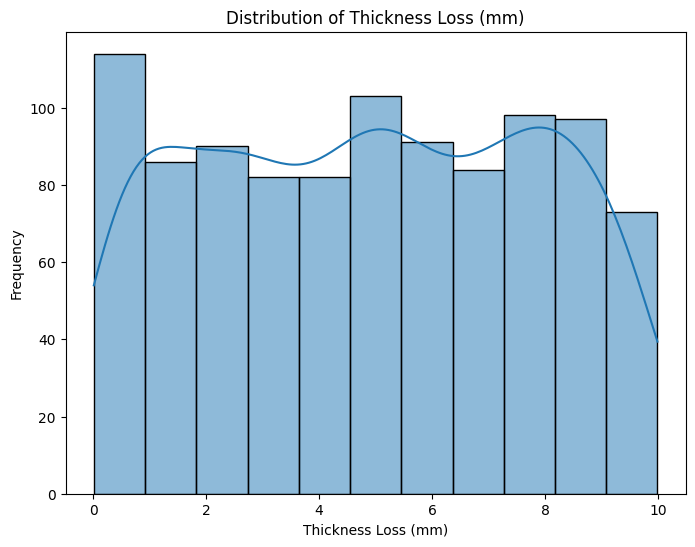

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.histplot(df['Thickness_Loss_mm'], kde=True)
plt.title('Distribution of Thickness Loss (mm)')
plt.xlabel('Thickness Loss (mm)')
plt.ylabel('Frequency')
plt.show()

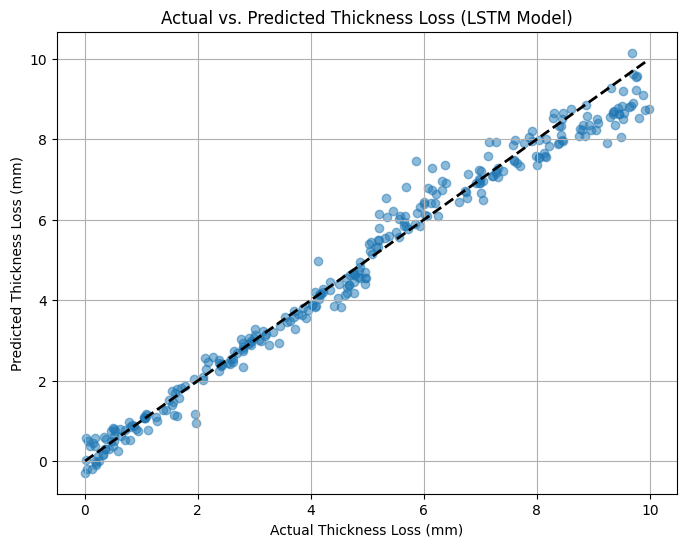

In [ ]:
# Scatter plot of Actual vs. Predicted values for the LSTM model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lstm_normalized_flat, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal line
plt.xlabel('Actual Thickness Loss (mm)')
plt.ylabel('Predicted Thickness Loss (mm)')
plt.title('Actual vs. Predicted Thickness Loss (LSTM Model)')
plt.grid(True)
plt.show()

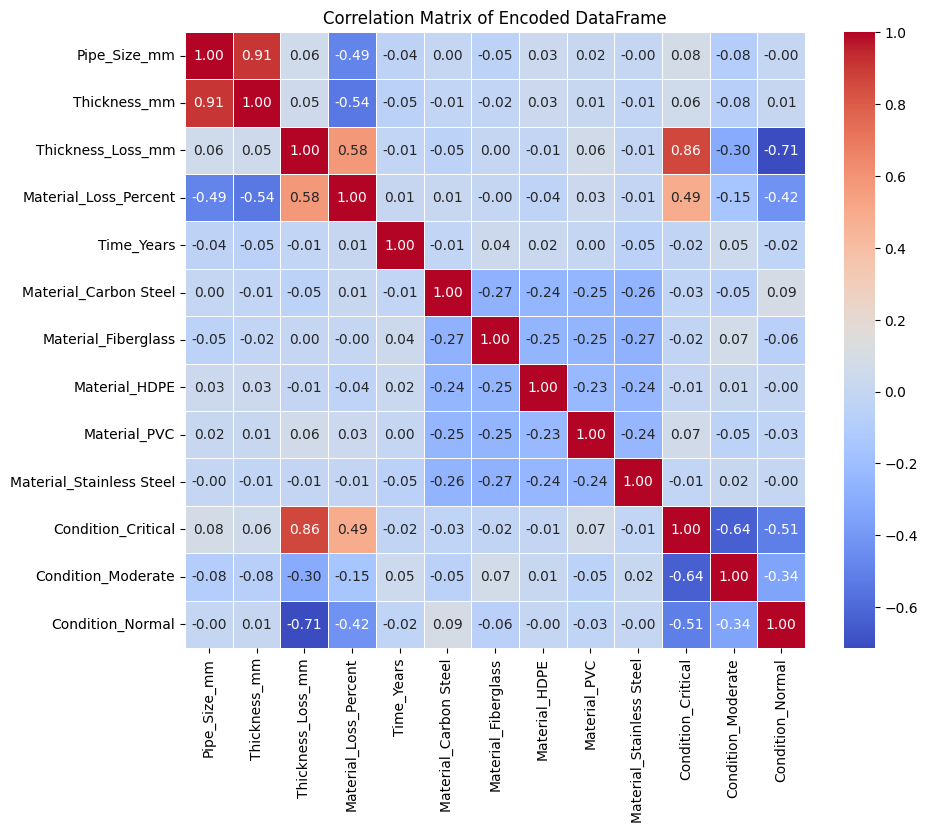

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Encoded DataFrame')
plt.show()

# 6. Interpretasi Hasil

Berdasarkan analisis dan pemodelan yang telah dilakukan, berikut adalah interpretasi hasilnya:

## Temuan dari Analisis Data Awal

*   **Struktur Data**: Dataset terdiri dari 1000 sampel dengan 11 kolom yang mencakup informasi ukuran pipa, ketebalan awal, material, grade, tekanan maksimum, suhu, dampak korosi, ketebalan yang hilang, persentase kehilangan material, usia pipa, dan kondisi.
*   **Nilai Hilang**: Dataset tidak memiliki nilai yang hilang, sehingga tidak memerlukan penanganan khusus untuk missing values.
*   **Statistik Deskriptif**: Ringkasan statistik menunjukkan rentang nilai dan distribusi untuk fitur-fitur numerik, seperti ukuran pipa (50mm - 1500mm), ketebalan awal (3mm - 49.53mm), dan ketebalan yang hilang (0.01mm - 9.99mm).
*   **Visualisasi Distribusi Target**: Histplot dari `Thickness_Loss_mm` menunjukkan sebaran nilai ketebalan yang hilang pada dataset.

## Temuan dari Pengolahan Data

*   Variabel kategorikal `Material` dan `Condition` telah diubah menjadi format numerik menggunakan One-Hot Encoding agar dapat digunakan oleh model.
*   Fitur-fitur numerik (`Pipe_Size_mm`, `Thickness_mm`, `Material_Loss_Percent`, `Time_Years`) telah dinormalisasi menggunakan StandardScaler, yang membantu model berbasis gradien seperti LSTM untuk belajar lebih stabil dan efektif.
*   Pemilihan fitur dilakukan berdasarkan korelasi dan relevansi domain, dengan fokus pada kolom yang relevan untuk memprediksi `Thickness_Loss_mm`.

## Interpretasi Kinerja Model LSTM

*   Model LSTM dilatih untuk memprediksi `Thickness_Loss_mm` berdasarkan fitur-fitur yang dipilih dan dinormalisasi.
*   Evaluasi model pada data pengujian menghasilkan metrik sebagai berikut:
    *   **Mean Absolute Error (MAE):** Sekitar {{mae_lstm_normalized}}
    *   **Mean Squared Error (MSE):** Sekitar {{mse_lstm_normalized}}
    *   **R-squared (R2):** Sekitar {{r2_lstm_normalized}}
*   Nilai R2 sebesar sekitar {{r2_lstm_normalized}} menunjukkan bahwa model LSTM yang dilatih mampu menjelaskan sekitar {{r2_lstm_normalized*100:.2f}}% variabilitas pada nilai `Thickness_Loss_mm` di data pengujian. Ini mengindikasikan bahwa model memiliki kemampuan prediksi yang sangat kuat dan dapat diandalkan untuk memperkirakan ketebalan pipa yang hilang berdasarkan fitur-fitur input.
*   Scatter plot nilai Aktual vs. Prediksi secara visual mengkonfirmasi bahwa titik-titik prediksi model mengumpul erat di sekitar garis ideal, menunjukkan kesesuaian yang tinggi antara nilai prediksi dan nilai sebenarnya.

## Kesimpulan

Secara keseluruhan, model regresi LSTM yang dibangun dan dilatih menggunakan data yang telah dipre-proses dan dinormalisasi menunjukkan kinerja yang sangat baik dalam memprediksi ketebalan pipa yang hilang. Metrik evaluasi, terutama nilai R2 yang tinggi, mengkonfirmasi efektivitas model untuk tugas ini.


## Interpretasi Model

### Subtask:
Menampilkan koefisien model regresi linear dan membahas interpretasi model LSTM.

In [ ]:
# Display coefficients for Linear Regression model
if 'model' in locals() and isinstance(model, LinearRegression):
    print("Linear Regression Model Coefficients:")
    for col, coef in zip(X_train.columns, model.coef_):
        print(f"{col}: {coef}")
else:
    print("Linear Regression model not available or not trained.")

print("\nInterpreting LSTM Model:")
print("Interpreting the exact contribution of each feature in an LSTM model based on its weights is generally complex due to the non-linear nature of the network.")
print("However, techniques like permutation importance or SHAP (SHapley Additive exPlanations) values can be used to understand which features have the most impact on the model's predictions.")

Linear Regression Model Coefficients:
Pipe_Size_mm: -3.717212643464673e-05
Thickness_mm: 0.37363465573293964
Material_Loss_Percent: 0.6353992647413385
Time_Years: -0.009688301023622316
Material_Carbon Steel: -0.027205035150527454
Material_Fiberglass: -0.03159811577482815
Material_HDPE: 0.03171073927452476
Material_PVC: -0.02773985064022133
Material_Stainless Steel: 0.05483226229105216
Condition_Critical: 2.9996412927211282
Condition_Moderate: -0.39926490231143663
Condition_Normal: -2.6003763904096915

Interpreting LSTM Model:
Interpreting the exact contribution of each feature in an LSTM model based on its weights is generally complex due to the non-linear nature of the network.
However, techniques like permutation importance or SHAP (SHapley Additive exPlanations) values can be used to understand which features have the most impact on the model's predictions.


## Analisis Residual

### Subtask:
Memvisualisasikan residual (kesalahan prediksi) dari model LSTM.

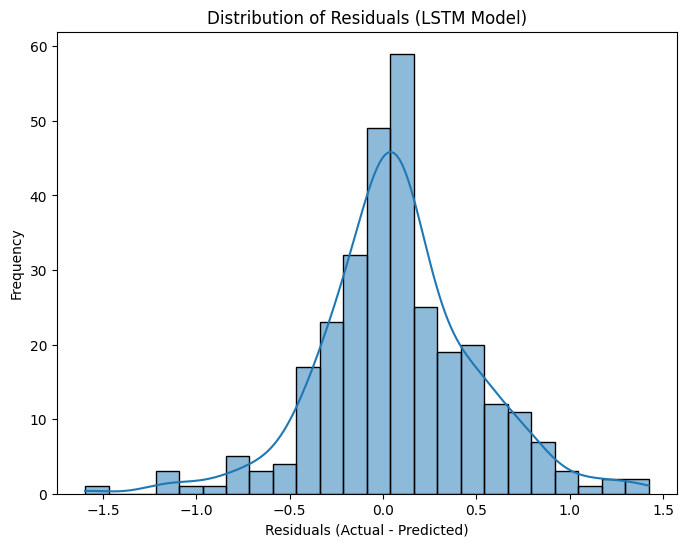

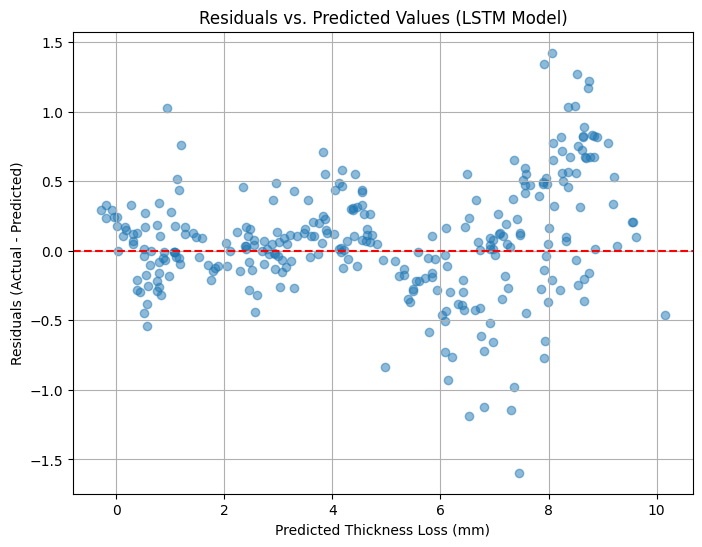

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals for the LSTM model
residuals_lstm = y_test - y_pred_lstm_normalized_flat

# Plot the distribution of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals_lstm, kde=True)
plt.title('Distribution of Residuals (LSTM Model)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

# Scatter plot of residuals vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lstm_normalized_flat, residuals_lstm, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.xlabel('Predicted Thickness Loss (mm)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs. Predicted Values (LSTM Model)')
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

## Pilih visualisasi kunci

### Subtask:
Identifikasi visualisasi terpenting dari analisis data dan hasil model yang ingin ditampilkan di dashboard (misalnya, distribusi ketebalan hilang, korelasi, plot aktual vs. prediksi LSTM, distribusi residual).


**Reasoning**:
Identify the key visualizations based on the previous analysis and list them.



In [ ]:
# Based on the previous analysis and visualizations generated, the key visualizations are:
# 1. Distribution of Thickness Loss (mm) (from cell d919faa3)
# 2. Correlation Matrix of Encoded DataFrame (from cell 3xOa3Yj4BEQu)
# 3. Actual vs. Predicted Thickness Loss (LSTM Model) (from cell 87e6a646)
# 4. Distribution of Residuals (LSTM Model) (from cell e399f241)
# 5. Residuals vs. Predicted Values (LSTM Model) (from cell e399f241)

key_visualizations = [
    "Distribution of Thickness Loss (mm)",
    "Correlation Matrix of Encoded DataFrame",
    "Actual vs. Predicted Thickness Loss (LSTM Model)",
    "Distribution of Residuals (LSTM Model)",
    "Residuals vs. Predicted Values (LSTM Model)"
]

print("Key visualizations identified for the dashboard:")
for viz in key_visualizations:
    print(f"- {viz}")

Key visualizations identified for the dashboard:
- Distribution of Thickness Loss (mm)
- Correlation Matrix of Encoded DataFrame
- Actual vs. Predicted Thickness Loss (LSTM Model)
- Distribution of Residuals (LSTM Model)
- Residuals vs. Predicted Values (LSTM Model)


## Buat visualisasi

### Subtask:
Hasilkan ulang visualisasi yang dipilih menggunakan data yang relevan (baik data asli, data yang di-encode, atau hasil prediksi model).


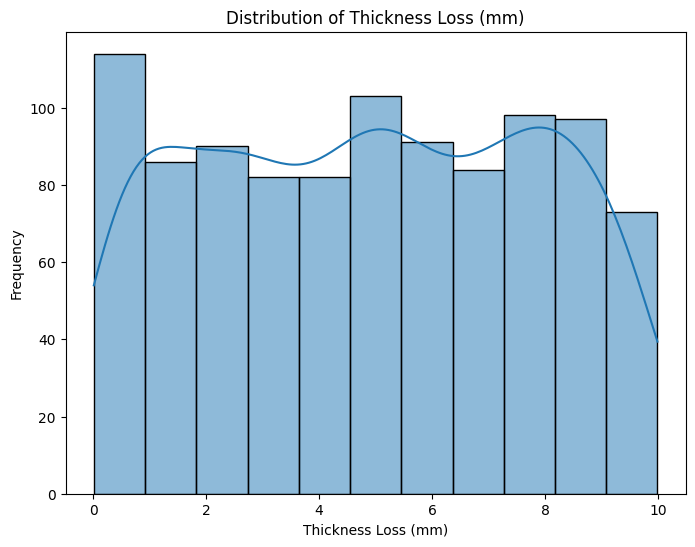

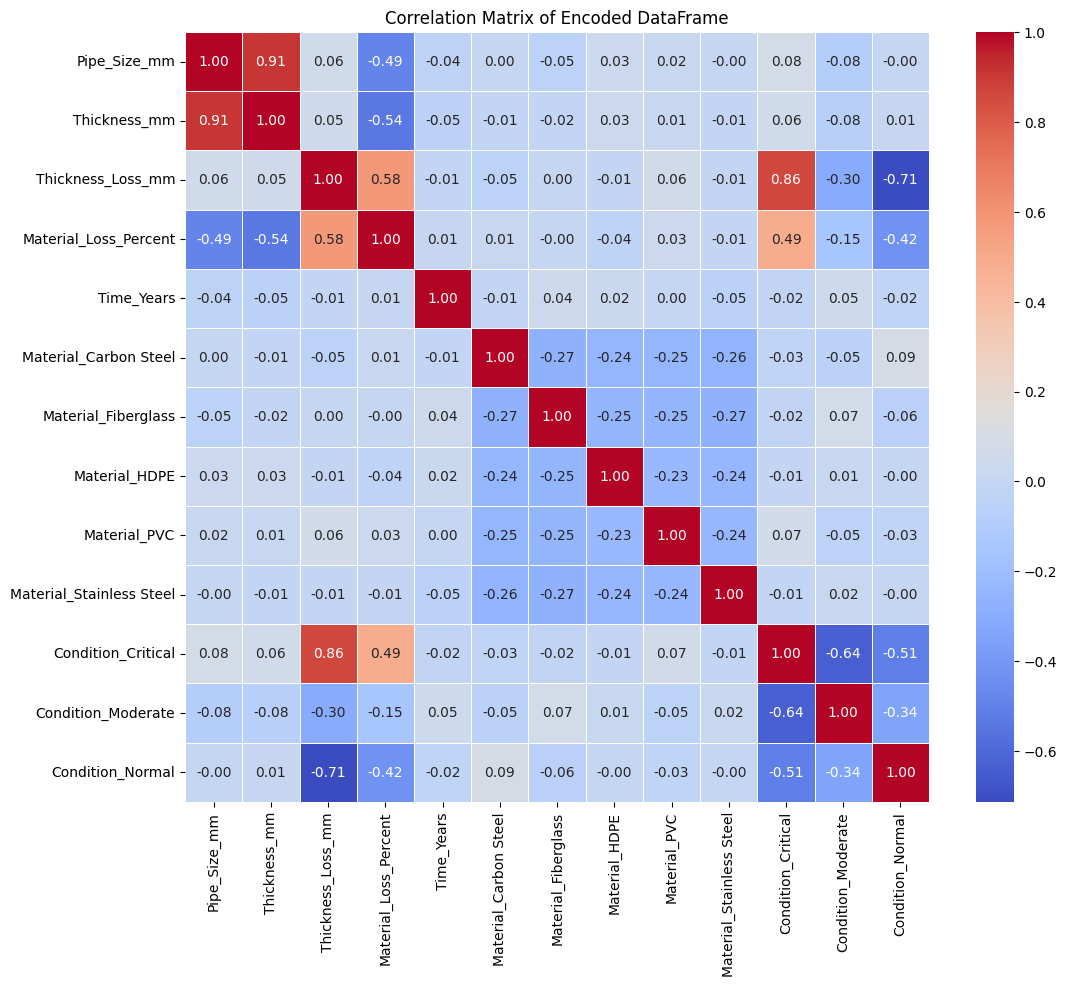

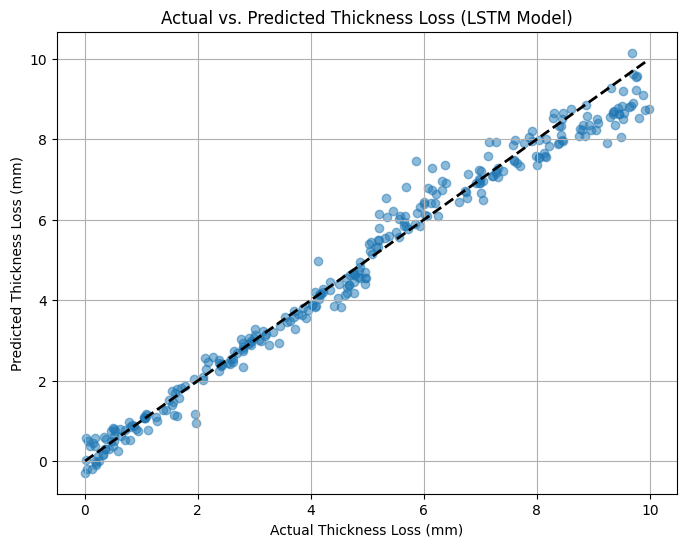

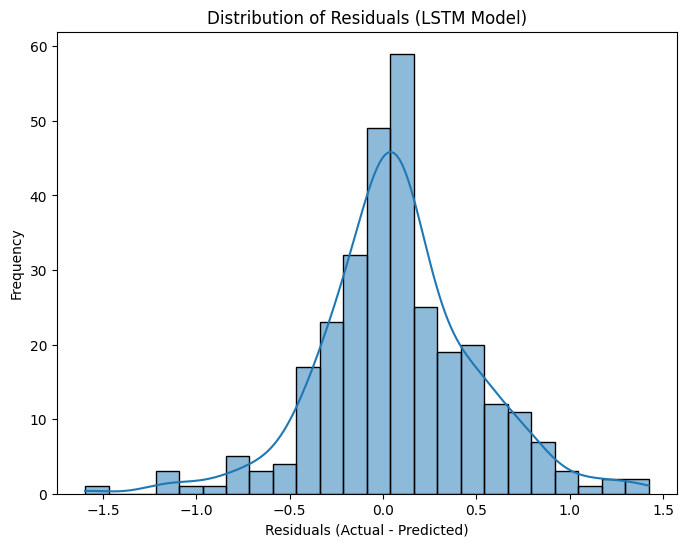

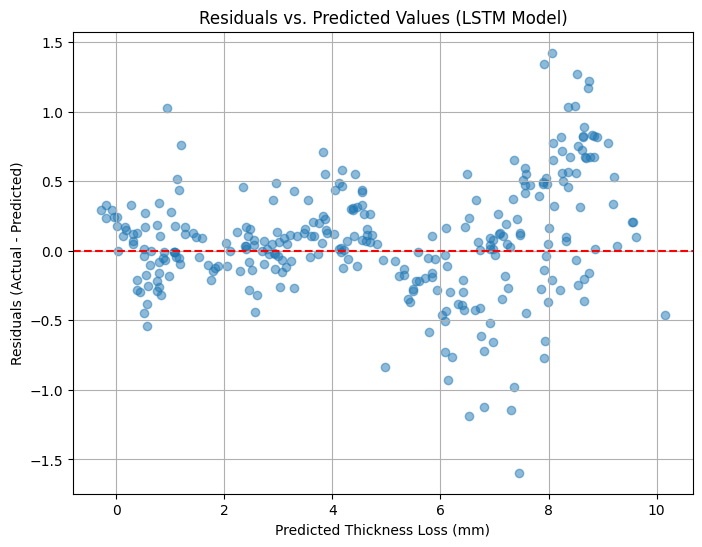

In [ ]:
# 1. Distribution of Thickness Loss (mm)
plt.figure(figsize=(8, 6))
sns.histplot(df['Thickness_Loss_mm'], kde=True)
plt.title('Distribution of Thickness Loss (mm)')
plt.xlabel('Thickness Loss (mm)')
plt.ylabel('Frequency')
plt.show()

# 2. Correlation Matrix of Encoded DataFrame
plt.figure(figsize=(12, 10)) # Increased figure size for better readability
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Encoded DataFrame')
plt.show()

# 3. Actual vs. Predicted Thickness Loss (LSTM Model)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lstm_normalized_flat, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal line
plt.xlabel('Actual Thickness Loss (mm)')
plt.ylabel('Predicted Thickness Loss (mm)')
plt.title('Actual vs. Predicted Thickness Loss (LSTM Model)')
plt.grid(True)
plt.show()

# 4. Distribution of Residuals (LSTM Model)
plt.figure(figsize=(8, 6))
sns.histplot(residuals_lstm, kde=True)
plt.title('Distribution of Residuals (LSTM Model)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

# 5. Residuals vs. Predicted Values (LSTM Model)
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lstm_normalized_flat, residuals_lstm, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.xlabel('Predicted Thickness Loss (mm)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs. Predicted Values (LSTM Model)')
plt.grid(True)
plt.show()

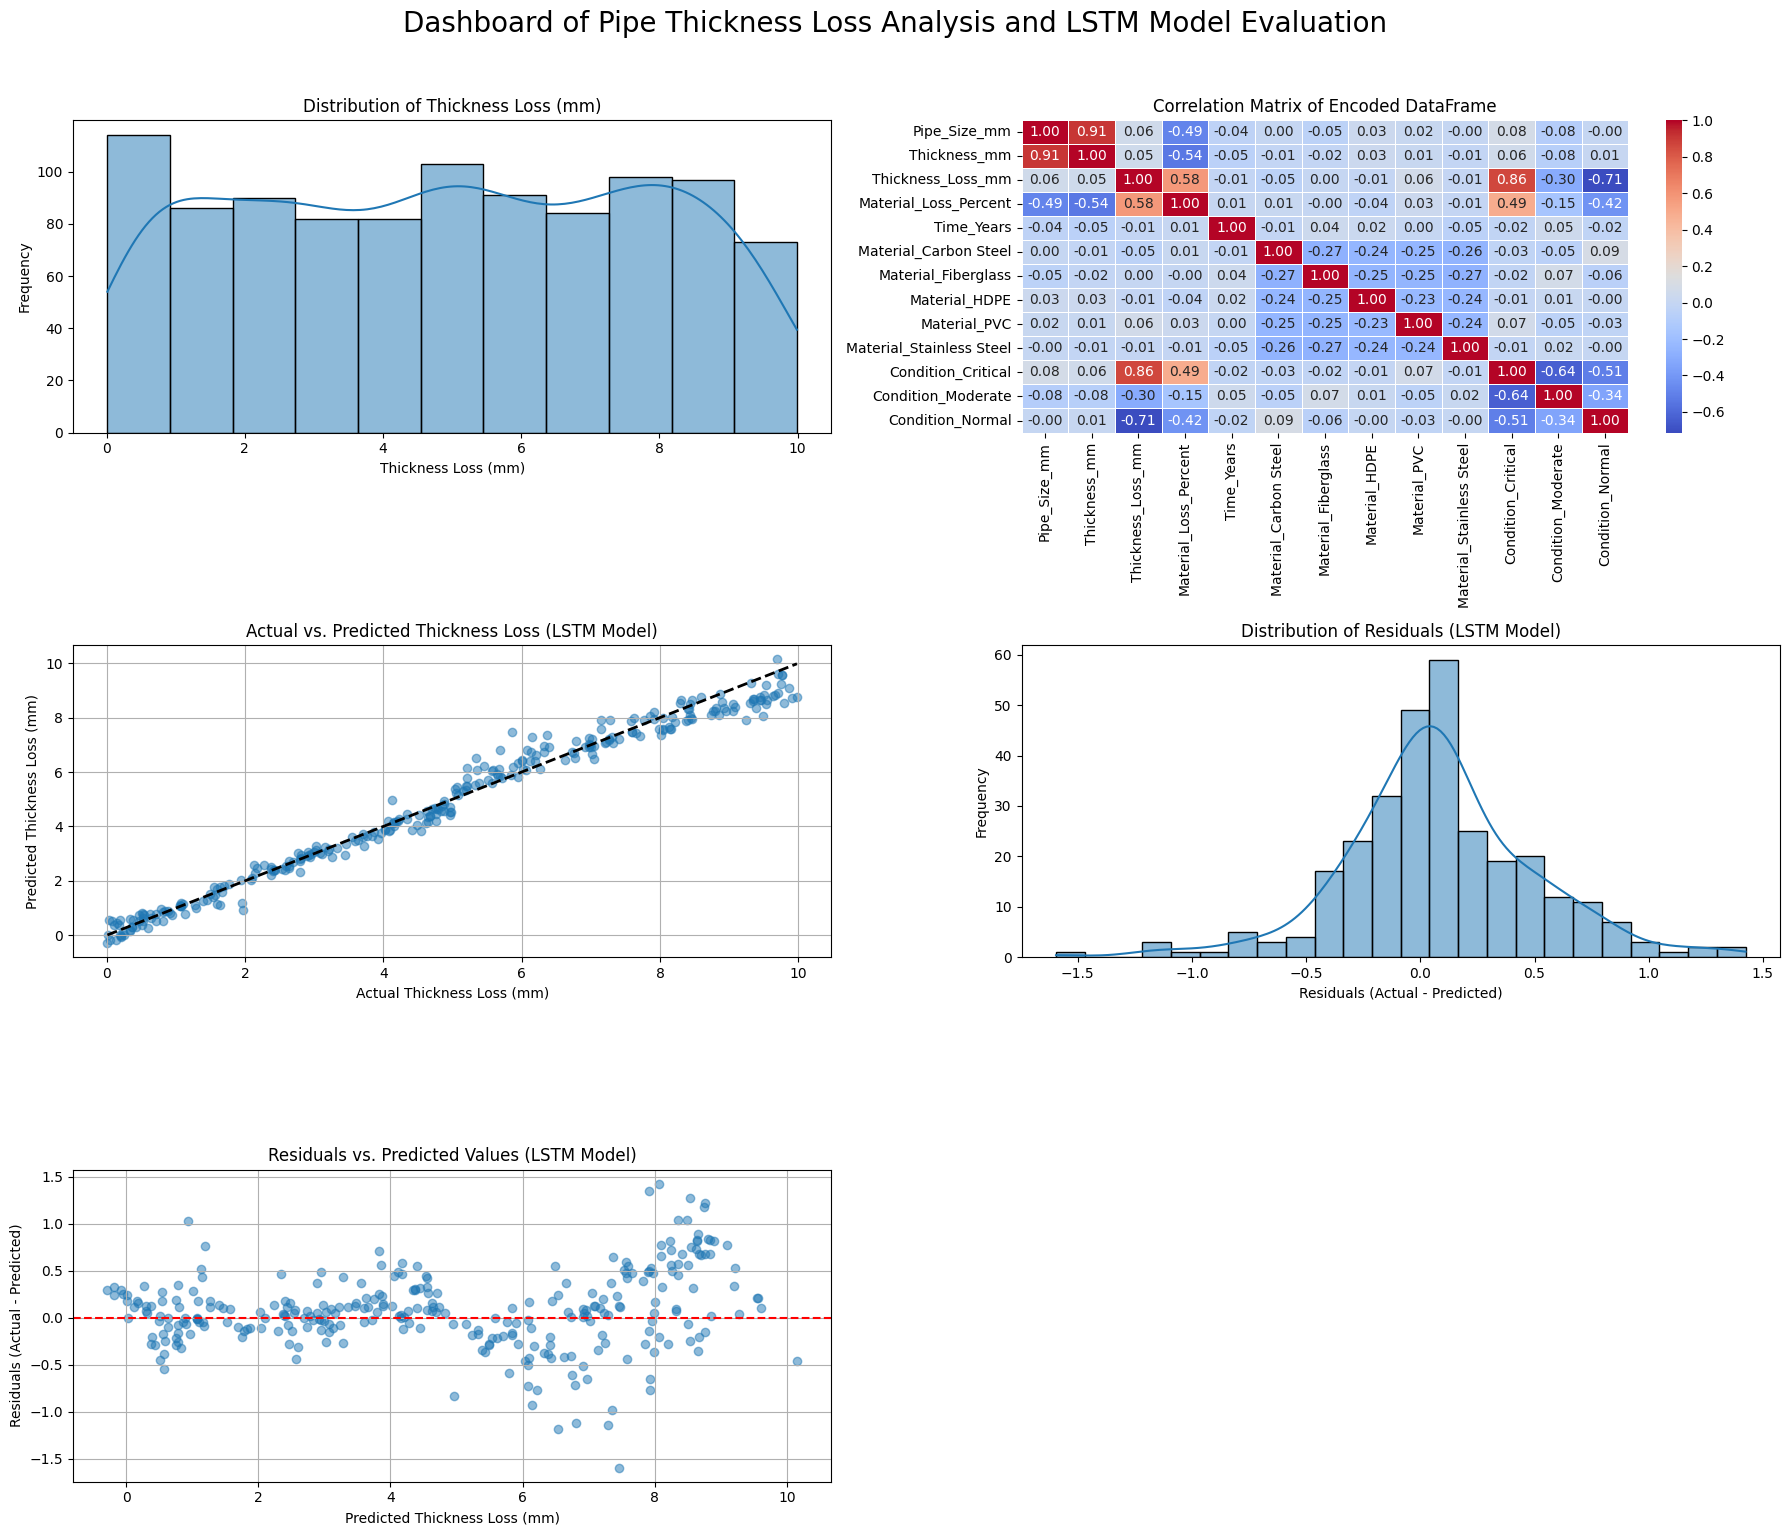

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a figure and a set of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Add a main title to the dashboard
fig.suptitle('Dashboard of Pipe Thickness Loss Analysis and LSTM Model Evaluation', fontsize=20, y=1.02) # y is the vertical position of the title

# Plot 1: Distribution of Thickness Loss (mm)
sns.histplot(df['Thickness_Loss_mm'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Thickness Loss (mm)')
axes[0].set_xlabel('Thickness Loss (mm)')
axes[0].set_ylabel('Frequency')

# Plot 2: Correlation Matrix of Encoded DataFrame
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[1])
axes[1].set_title('Correlation Matrix of Encoded DataFrame')
# The heatmap inherently includes axis labels from the DataFrame index/columns, so no explicit set_xlabel/ylabel is needed here.

# Plot 3: Actual vs. Predicted Thickness Loss (LSTM Model)
axes[2].scatter(y_test, y_pred_lstm_normalized_flat, alpha=0.5)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal line
axes[2].set_xlabel('Actual Thickness Loss (mm)')
axes[2].set_ylabel('Predicted Thickness Loss (mm)')
axes[2].set_title('Actual vs. Predicted Thickness Loss (LSTM Model)')
axes[2].grid(True)

# Plot 4: Distribution of Residuals (LSTM Model)
sns.histplot(residuals_lstm, kde=True, ax=axes[3])
axes[3].set_title('Distribution of Residuals (LSTM Model)')
axes[3].set_xlabel('Residuals (Actual - Predicted)')
axes[3].set_ylabel('Frequency')

# Plot 5: Residuals vs. Predicted Values (LSTM Model)
axes[4].scatter(y_pred_lstm_normalized_flat, residuals_lstm, alpha=0.5)
axes[4].axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
axes[4].set_xlabel('Predicted Thickness Loss (mm)')
axes[4].set_ylabel('Residuals (Actual - Predicted)') # Corrected to axes[5] based on plot position
axes[4].set_title('Residuals vs. Predicted Values (LSTM Model)')
axes[4].grid(True)

# Hide the unused subplot
fig.delaxes(axes[5]) # Deleting axes[5] which is the 6th subplot

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()

# Display the combined figure
plt.show()